In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import eig

plt.style.use('seaborn-v0_8-whitegrid')

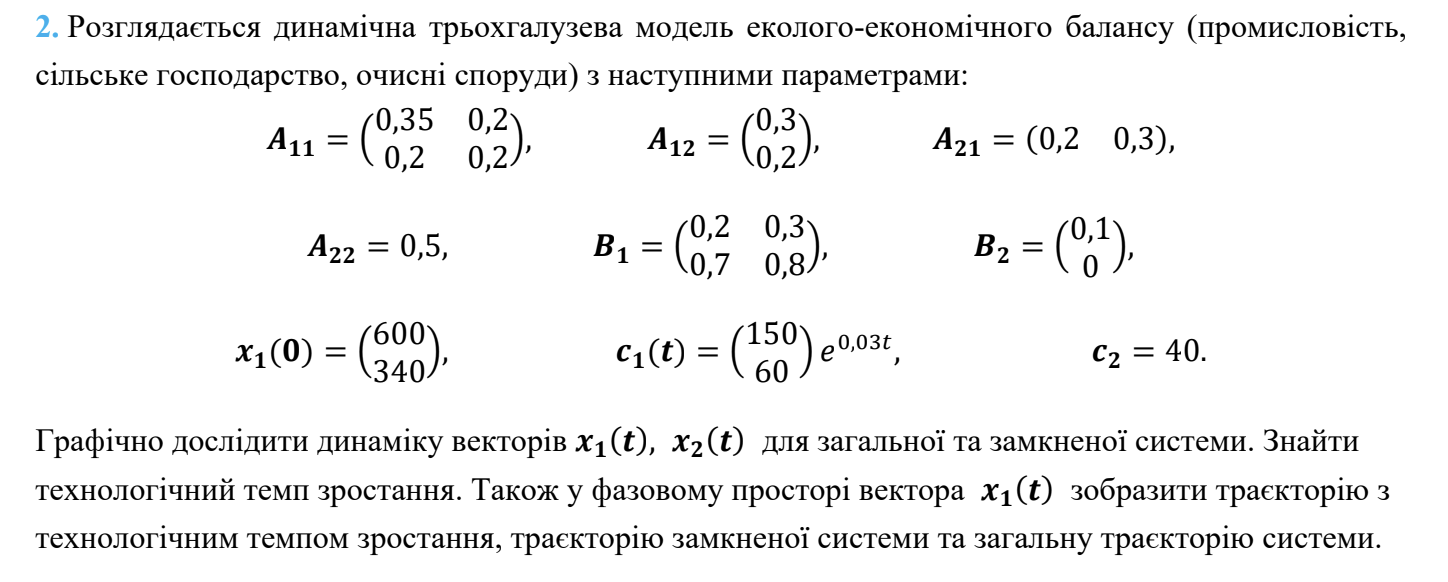

In [2]:
A11 = np.array([[0.35, 0.2], [0.2, 0.2]])
A12 = np.array([[0.3], [0.2]])
A21 = np.array([[0.2, 0.3]])
A22 = 0.5

B1 = np.array([[0.2, 0.3], [0.7, 0.8]])
B2 = np.array([[0.1], [0.0]])

x1_0 = np.array([600, 340])
c2 = 40

def c1(t):
    return np.array([150, 60]) * np.exp(0.03 * t)

## Зведення розмірності системи
Оскільки матриця $B_2$ містить нулі для другої змінної, ми аналітично виражаємо $x_2(t)$ через $x_1(t)$ та підставляємо в перше рівняння. 
Отримуємо зведені матриці $\tilde{A}$ та $\tilde{B}$, а також головну матрицю динаміки $M = \tilde{B}^{-1}(E - \tilde{A})$.

In [3]:
A_tilde = A11 + 2 * A12 @ A21
B_tilde = B1 + 2 * B2 @ A21

E = np.eye(2)
B_tilde_inv = np.linalg.inv(B_tilde)
M = B_tilde_inv @ (E - A_tilde)

## Знаходження технологічного темпу зростання
Технологічний темп зростання $\alpha$ визначається як додатне дійсне власне значення матриці $M$. Відповідний йому власний вектор задає напрямок магістралі у фазовому просторі.

In [4]:
eigenvalues, eigenvectors = eig(M)

real_idx = [i for i, val in enumerate(eigenvalues) if np.isreal(val) and val > 0]
lambda_tech = np.real(eigenvalues[real_idx[0]])
v_tech = np.real(eigenvectors[:, real_idx[0]])

if v_tech[0] < 0:
    v_tech = -v_tech

print(f"Технологічний темп зростання (α): {lambda_tech:.4f}")
print(f"Магістральний вектор: {v_tech}")

Технологічний темп зростання (α): 0.2619
Магістральний вектор: [0.7124636  0.70170907]


## Визначення систем диференціальних рівнянь
Задаємо функції для розв'язання задачі Коші. 
* Замкнена система: $\dot{x}_1 = M x_1$ (кінцеве споживання дорівнює нулю).
* Загальна система: $\dot{x}_1 = M x_1 - \tilde{B}^{-1}\tilde{c}(t)$.

In [5]:
def closed_system(t, x):
    return M @ x

def general_system(t, x):
    c_tilde = c1(t) + 2 * A12.flatten() * c2
    return M @ x - B_tilde_inv @ c_tilde

## Чисельне розв'язання на інтервалі часу
Використовуємо метод `solve_ivp` з бібліотеки SciPy для інтегрування систем на проміжку $t \in [0, 10]$. Після знаходження $x_1(t)$ відновлюємо динаміку для очисних споруд $x_2(t)$.

In [ ]:
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 500)

sol_closed = solve_ivp(closed_system, t_span, x1_0, t_eval=t_eval)
sol_general = solve_ivp(general_system, t_span, x1_0, t_eval=t_eval)

x2_closed = 2 * A21 @ sol_closed.y
x2_general = 2 * A21 @ sol_general.y + 2 * c2

## Побудова графіків (Динаміка та Фазовий простір)
Візуалізуємо динаміку випусків усіх трьох галузей у часі, а також будуємо фазовий портрет для вектора $x_1(t)$, де відображаємо траєкторії загальної та замкненої систем разом із променем технологічного темпу зростання.

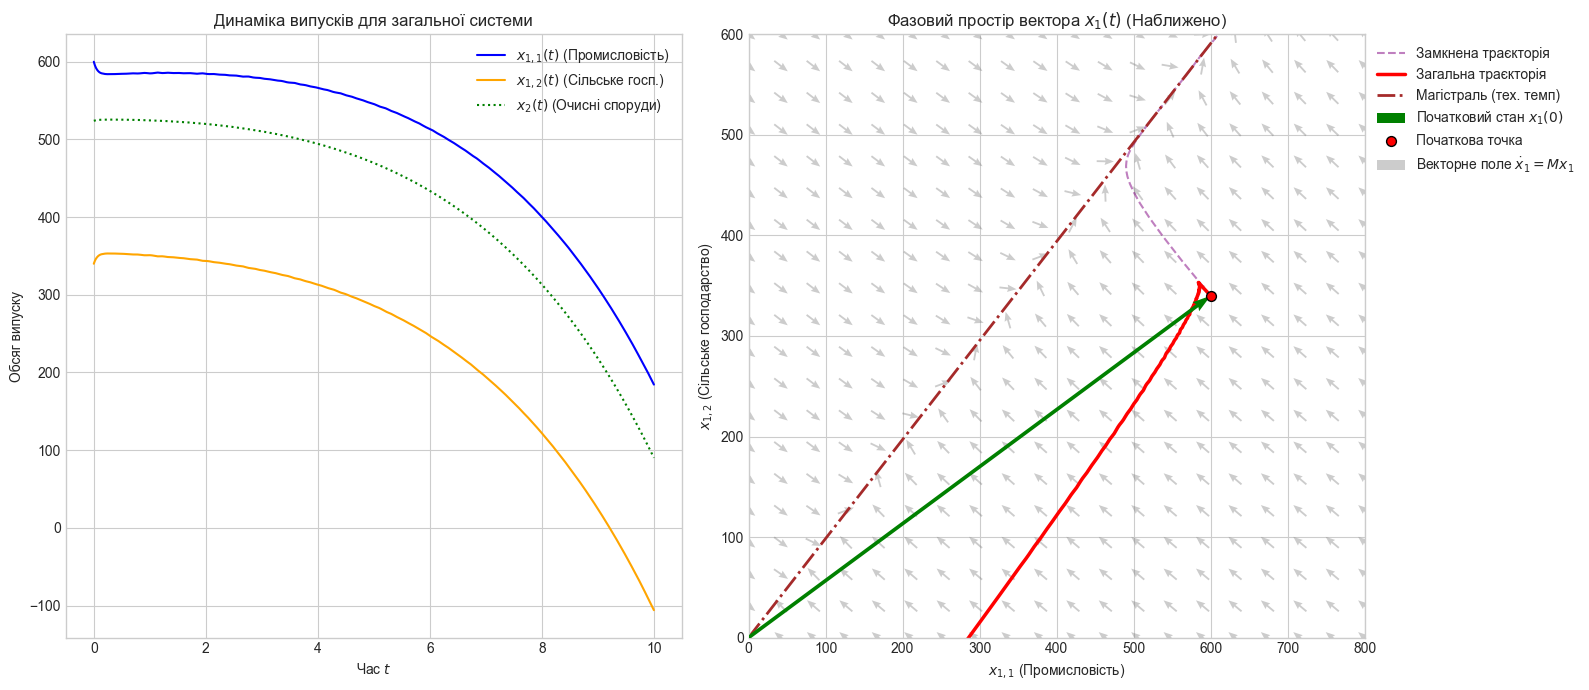

In [16]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.plot(sol_general.t, sol_general.y[0], label='$x_{1,1}(t)$ (Промисловість)', color='blue')
plt.plot(sol_general.t, sol_general.y[1], label='$x_{1,2}(t)$ (Сільське госп.)', color='orange')
plt.plot(sol_general.t, x2_general.flatten(), label='$x_2(t)$ (Очисні споруди)', color='green', linestyle=':')
plt.title('Динаміка випусків для загальної системи')
plt.xlabel('Час $t$')
plt.ylabel('Обсяг випуску')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(sol_closed.y[0], sol_closed.y[1], '--', label='Замкнена траєкторія', color='purple', linewidth=1.5, alpha=0.5)
plt.plot(sol_general.y[0], sol_general.y[1], label='Загальна траєкторія', color='red', linewidth=2.5)

zoom_x_max = 800
zoom_y_max = 600

t_ray = np.linspace(0, zoom_x_max, 100)
ray_y = (v_tech[1] / v_tech[0]) * t_ray
plt.plot(t_ray, ray_y, '-.', color='brown', label='Магістраль (тех. темп)', linewidth=2)


plt.quiver(0, 0, x1_0[0], x1_0[1], angles='xy', scale_units='xy', scale=1, 
           color='green', width=0.006, zorder=5, label='Початковий стан $x_1(0)$')

plt.scatter(x1_0[0], x1_0[1], color='red', s=50, zorder=10, marker='o', edgecolors='black', label='Початкова точка')

X, Y = np.meshgrid(np.linspace(0, zoom_x_max, 20), np.linspace(0, zoom_y_max, 20))
U = M[0, 0] * X + M[0, 1] * Y
V = M[1, 0] * X + M[1, 1] * Y
norm = np.hypot(U, V)
norm[norm == 0] = 1 
U_norm = U / norm
V_norm = V / norm

plt.quiver(X, Y, U_norm, V_norm, color='gray', alpha=0.4, pivot='mid', 
           headwidth=4, headlength=5, label=r'Векторне поле $\dot{x}_1 = M x_1$')

plt.title('Фазовий простір вектора $x_1(t)$ (Наближено)')
plt.xlabel('$x_{1,1}$ (Промисловість)')
plt.ylabel('$x_{1,2}$ (Сільське господарство)')

plt.xlim(0, zoom_x_max)
plt.ylim(0, zoom_y_max)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)

plt.tight_layout()
plt.show()